In [1]:
pip install shap scikit-learn pandas matplotlib

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.2 MB 2.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.2 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 2.3 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 2.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import shap
print(shap.__version__)

C:\Users\PriyaKetanKanere\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


0.51.0


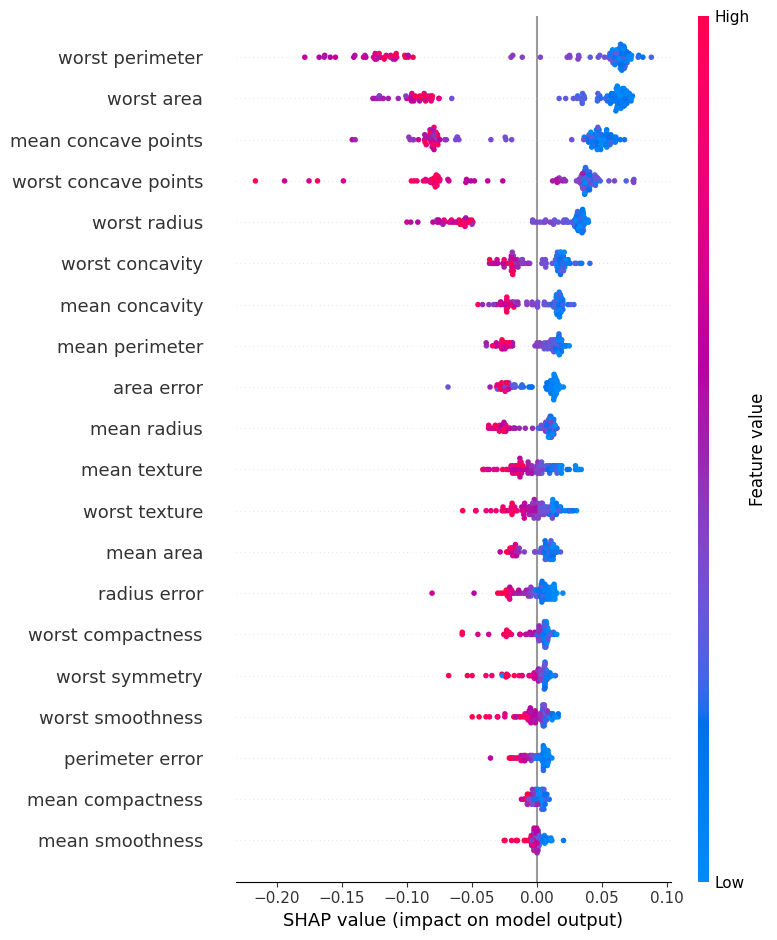

In [3]:
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# SHAP Explainer
explainer = shap.TreeExplainer(model)

# SHAP values
shap_values = explainer.shap_values(X_test)

# Global Feature Importance
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    feature_names=data.feature_names
)